In [25]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error
sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

In [26]:
df_raw = pd.read_csv('zameen_lahore_dataset.csv')
df_raw.head()

,Location,Beds,Baths,Title,Added_Date,Price_thnds,Area_sqft
0,"DHA Phase 1, DHA Defence",5.0,6.0,2 KANAL OWNER BUILD SPANISH BUNGALOW FOR SALE ...,Added: 1 hour ago,160000000.0,10890.00
1,"Lake City Meadows, Lahore",3.0,4.0,Brand New Modern House With Gas,Added: 3 hours ago,22500000.0,1361.25
2,NaN,NaN,NaN,NaN,NaN,28800000.0,NaN
3,"FCC, Gulberg 4",4.0,5.0,Syed Maratab Ali Road 1 Kanal Double Storey House,Added: 6 hours ago,140000000.0,5445.00
4,"Eden Boulevard Housing Scheme, College Road",4.0,5.0,4.5 MARLA FACING PARK DOUBLE STORY HOUSE FOR S...,Added: 8 hours ago,16500000.0,1089.00


In [27]:
df = pd.read_csv("zameen_lahore_dataset.csv")
df_raw.info()
df_raw.describe()
df_raw.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2673 entries, 0 to 2672
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Location     2475 non-null   object 
 1   Beds         2417 non-null   float64
 2   Baths        2415 non-null   float64
 3   Title        2475 non-null   object 
 4   Added_Date   2475 non-null   object 
 5   Price_thnds  2673 non-null   float64
 6   Area_sqft    2475 non-null   float64
dtypes: float64(4), object(3)
memory usage: 146.3+ KB


Location       198
Beds           256
Baths          258
Title          198
Added_Date     198
Price_thnds      0
Area_sqft      198
dtype: int64

In [28]:
df['locality'] = df['Location'].str.split(',').str[-1].str.strip()

In [29]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['locality_enc'] = le.fit_transform(df['locality'])

In [30]:
df['area_log'] = np.log1p(df['Area_sqft'])
df['bath_bed_ratio'] = df['Baths'] / df['Beds']
df = df.replace([np.inf, -np.inf], np.nan)
df = df.dropna()

In [31]:
FEATURES = ['Area_sqft', 'area_log', 'Beds', 'Baths',
            'bath_bed_ratio', 'locality_enc']

TARGET = 'Price_thnds'

X = df[FEATURES]
y = df[TARGET]

In [32]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [33]:
scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)  
X_test_sc  = scaler.transform(X_test)       
print('Scaling applied — mean ~0, std ~1 per feature')
print(pd.DataFrame(X_train_sc, columns=FEATURES).describe().round(2))

Scaling applied — mean ~0, std ~1 per feature
       Area_sqft  area_log     Beds    Baths  bath_bed_ratio  locality_enc
count    1912.00   1912.00  1912.00  1912.00         1912.00       1912.00
mean       -0.00      0.00     0.00     0.00            0.00          0.00
std         1.00      1.00     1.00     1.00            1.00          1.00
min        -0.76     -3.53    -2.46    -2.91           -3.27         -2.05
25%        -0.52     -0.88    -1.00    -0.75           -0.98         -0.49
50%        -0.24     -0.02     0.46    -0.02            0.17         -0.31
75%         0.30      0.85     0.46     0.70            0.45          0.89
max        16.67      4.31     4.83     2.14            6.66          2.71


In [34]:
gbr = GradientBoostingRegressor(
    n_estimators    = 300,
    learning_rate   = 0.08,
    max_depth       = 4,
    subsample       = 0.85,
    min_samples_leaf= 5,
    random_state    = 42
)
gbr.fit(X_train, y_train)         
y_pred_gbr = gbr.predict(X_test)
print('Gradient Boosting Regressor — trained ✓')
print(f'Number of estimators : {gbr.n_estimators_}')

Gradient Boosting Regressor — trained ✓
Number of estimators : 300


In [35]:
from sklearn.metrics import r2_score
lr = LinearRegression()
lr.fit(X_train_sc, y_train)
y_pred_lr = lr.predict(X_test_sc)
print("Linear Regression — trained and predicted ✓")

Linear Regression — trained and predicted ✓


In [36]:
def evaluate(y_true, y_pred, model_name):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    print(f'{'─'*50}')
    print(f'  {model_name}')
    print(f'  MAE  : PKR {mae/1e6:.2f} Million')
    print(f'  RMSE : PKR {rmse/1e6:.2f} Million')
    print(f'  R²   : {r2:.4f}')
    print(f'  MAPE : {mape:.1f}%')
    return dict(Model=model_name, MAE=mae, RMSE=rmse, R2=r2, MAPE=mape)
res_lr  = evaluate(y_test.values, y_pred_lr,  'Linear Regression')
res_gbr = evaluate(y_test.values, y_pred_gbr, 'Gradient Boosting')
print(f'{'─'*50}')

──────────────────────────────────────────────────
  Linear Regression
  MAE  : PKR 32.36 Million
  RMSE : PKR 53.56 Million
  R²   : 0.5234
  MAPE : 87.4%
──────────────────────────────────────────────────
  Gradient Boosting
  MAE  : PKR 16.96 Million
  RMSE : PKR 37.59 Million
  R²   : 0.7652
  MAPE : 24.4%
──────────────────────────────────────────────────


In [37]:
results_df = pd.DataFrame([res_lr, res_gbr]).set_index('Model')
results_df['MAE']  = results_df['MAE'].apply(lambda x: f'PKR {x/1e6:.2f}M')
results_df['RMSE'] = results_df['RMSE'].apply(lambda x: f'PKR {x/1e6:.2f}M')
results_df['R2']   = results_df['R2'].apply(lambda x: f'{x:.4f}')
results_df['MAPE'] = results_df['MAPE'].apply(lambda x: f'{x:.1f}%')
results_df

,MAE,RMSE,R2,MAPE
Model,,,,
Linear Regression,PKR 32.36M,PKR 53.56M,0.5234,87.4%
Gradient Boosting,PKR 16.96M,PKR 37.59M,0.7652,24.4%


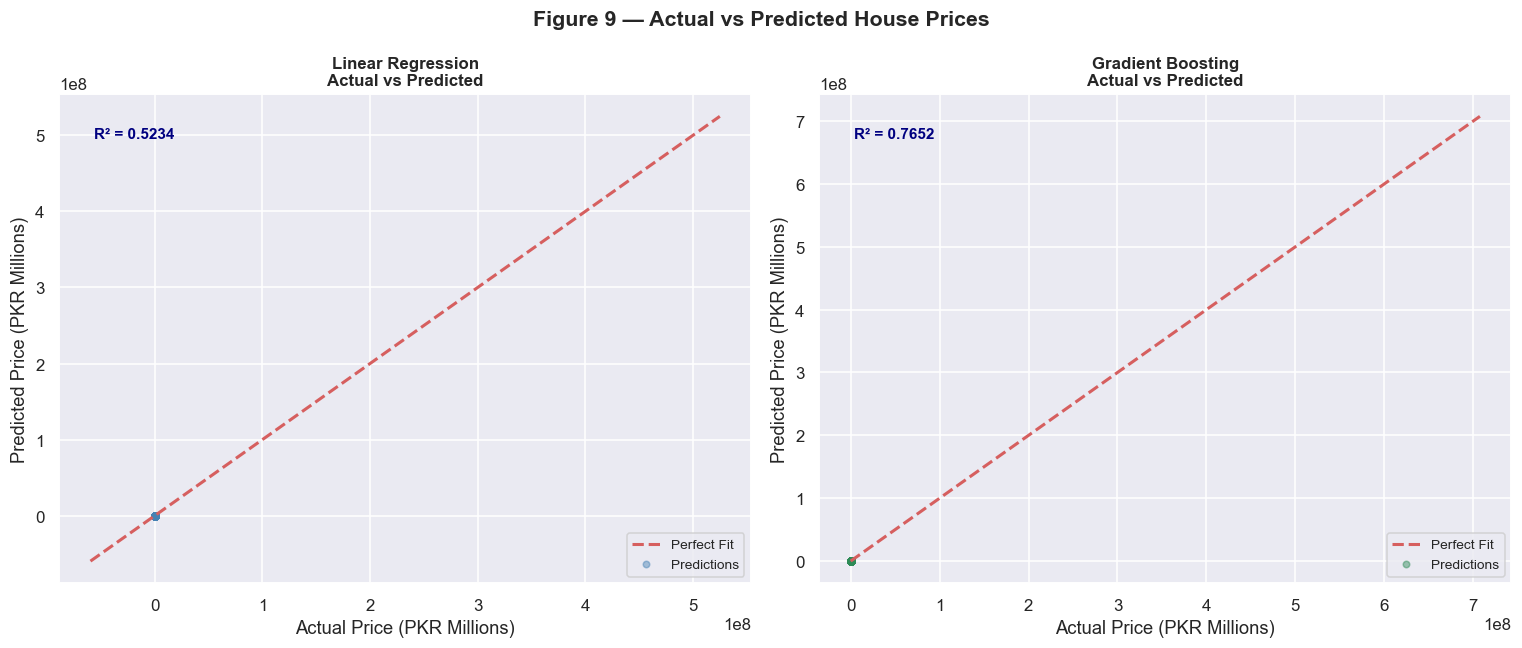

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, yt, yp, title, col in [
    (axes[0], y_test.values, y_pred_lr,  'Linear Regression',  'steelblue'),
    (axes[1], y_test.values, y_pred_gbr, 'Gradient Boosting',  'seagreen'),
]:
    lo = min(yt.min(), yp.min()) * 0.9
    hi = max(yt.max(), yp.max()) * 1.05
    ax.plot([lo, hi], [lo, hi], 'r--', lw=2, label='Perfect Fit')
    ax.scatter(yt/1e6, yp/1e6, color=col, alpha=0.45, s=18, label='Predictions')
    ax.set_title(f'{title}\nActual vs Predicted', fontsize=11, fontweight='bold')
    ax.set_xlabel('Actual Price (PKR Millions)')
    ax.set_ylabel('Predicted Price (PKR Millions)')
    r2 = r2_score(yt, yp)
    ax.text(0.05, 0.91, f'R² = {r2:.4f}', transform=ax.transAxes,
            fontsize=10, fontweight='bold', color='navy')
    ax.legend(fontsize=9)
plt.suptitle('Figure 9 — Actual vs Predicted House Prices',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()